In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [3]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas
 
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
], dtype=np.float32)

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

In [4]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

def gabung_tepi(*edges):
    gabungan = np.zeros_like(edges[0], dtype=np.float32)
    for e in edges:
        gabungan += e.astype(np.float32)
    gabungan = gabungan * 255.0 / np.max(gabungan)
    return np.clip(gabungan, 0, 255).astype(np.uint8)

sobelx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]],dtype=np.float32)
sobely = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=np.float32)

prewittx = np.array([[-1, 0, 1],
                      [-1, 0, 1], 
                      [-1, 0, 1]], dtype=np.float32)
prewitty = np.array([[1, 1, 1], 
                      [0, 0, 0], 
                      [-1, -1, -1]], dtype=np.float32)

robertsx = np.array([[1, 0], 
                     [0, -1]], dtype=np.float32)
robertsy = np.array([[0, 1], 
                     [-1, 0]], dtype=np.float32)

In [5]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

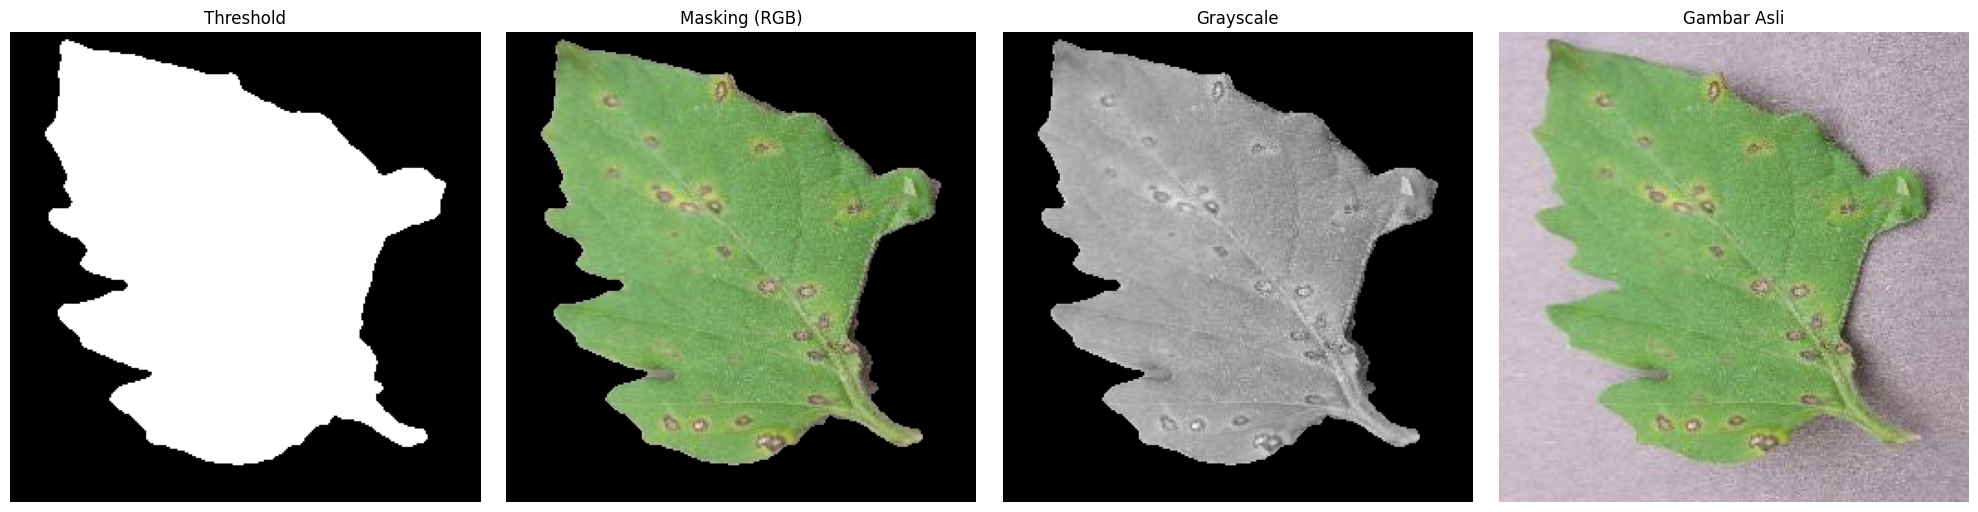

In [6]:
daun_bgr = cv.imread('archive/tomato/septoria.JPG')
daun_rgb = cv.cvtColor(daun_bgr, cv.COLOR_BGR2RGB)

# 1. KONVERSI KE HSV UNTUK MENGAMBIL CHANNEL SATURATION
daun_hsv = cv.cvtColor(daun_bgr, cv.COLOR_BGR2HSV)

tinggi, lebar = daun_rgb.shape[:2]
mask_fg = np.zeros((tinggi, lebar), dtype=np.uint8)

# 2. THRESHOLD CHANNEL WARNA (SATURATION)
for i in range(tinggi):
    for j in range(lebar):
        # Ambil nilai Saturation (Indeks ke-1 dari HSV)
        sat = daun_hsv[i, j, 1]
        
        # Jika warna pekat (Daun & Penyakit), jadikan Putih. 
        # Jika pudar (Background Abu-abu), jadikan Hitam.
        # Angka 35 adalah batas sensitivitas.
        if sat > 35:
            mask_fg[i, j] = 255
        else:
            mask_fg[i, j] = 0

mask_fg_clean = filter(mask_fg, 5, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

# 3. MASKING KE GAMBAR RGB
for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_clean[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

daun_akhir_gray = cv.cvtColor(daun_removed, cv.COLOR_RGB2GRAY)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(mask_fg_clean, cmap='gray')
plt.title('Threshold')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(daun_removed)
plt.title('Masking (RGB)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(daun_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.tight_layout()
plt.show()

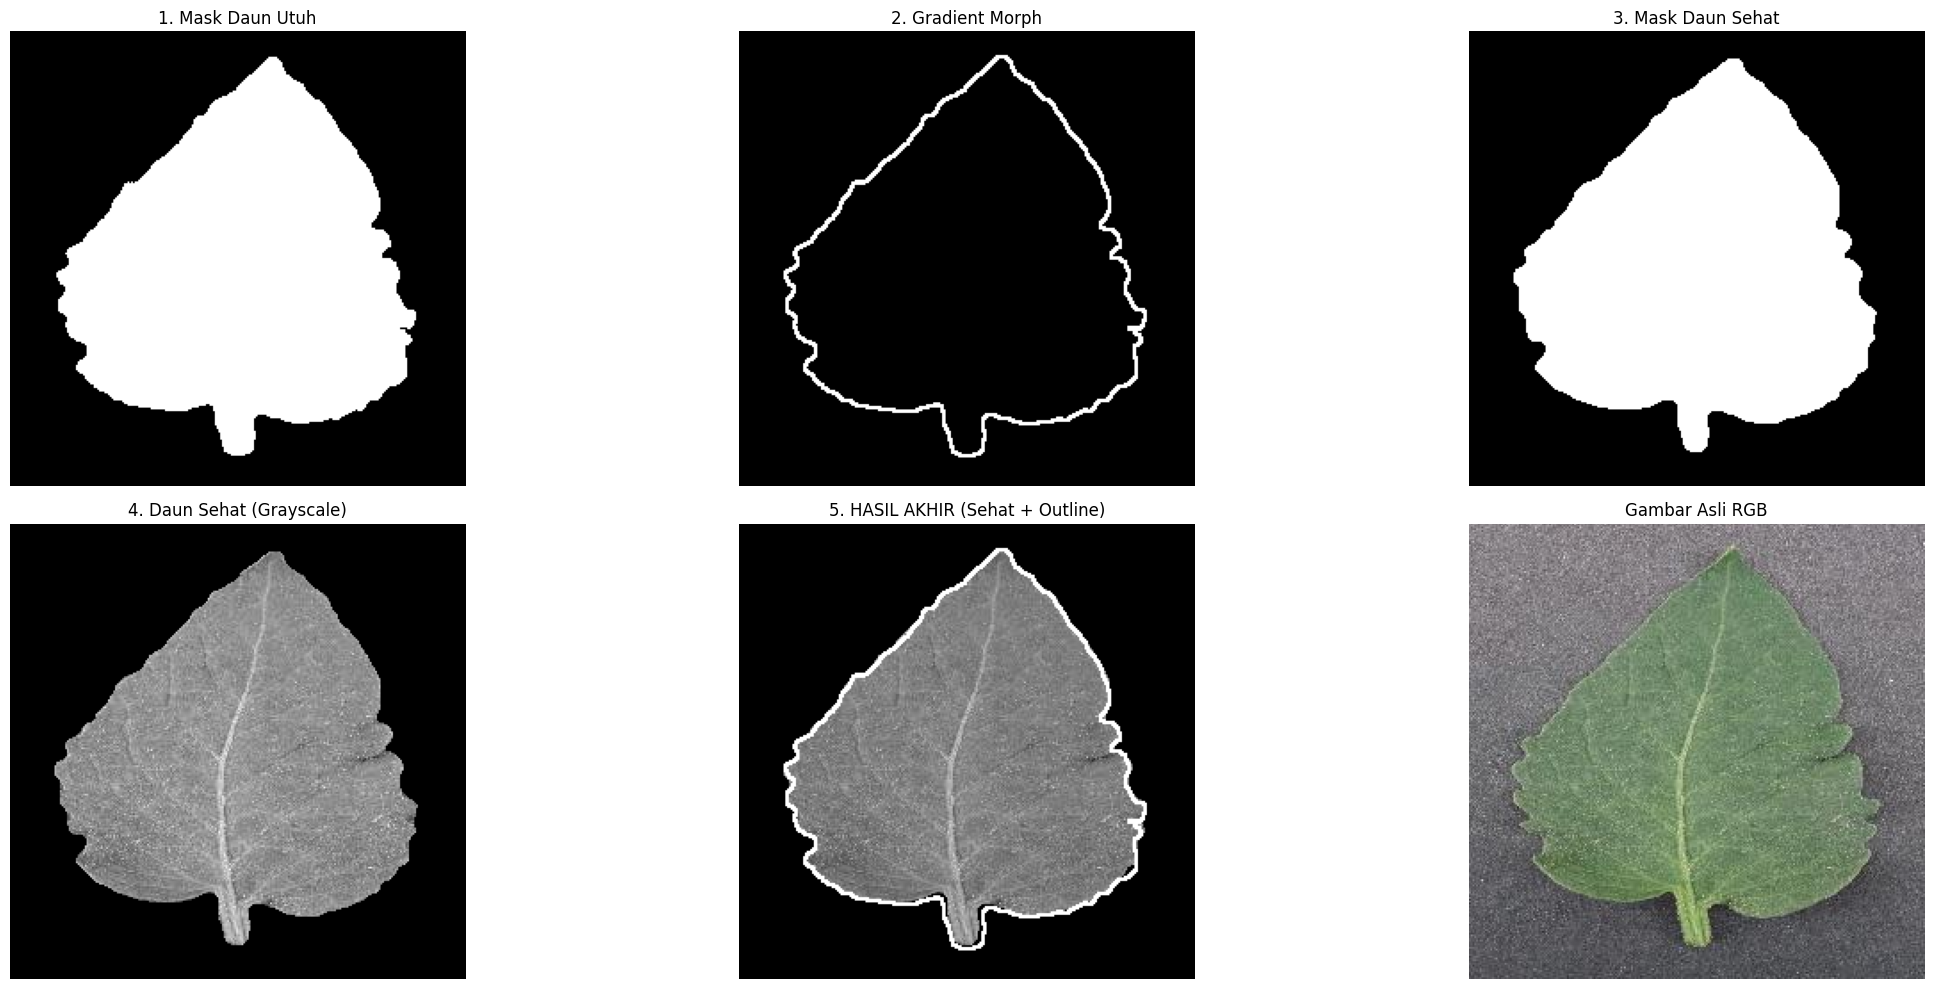

In [11]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
    return hasil

def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

def gradient_morph(image, kernel):
    hasil_dilasi = dilasi(image, kernel)
    hasil_erosi = erosi(image, kernel)
    hasil_gradient = np.clip(hasil_dilasi.astype(np.int16) - hasil_erosi.astype(np.int16), 0, 255).astype(np.uint8)
    return hasil_gradient

daun_bgr = cv.imread('archive/tomato/healty.JPG')
daun_rgb = cv.cvtColor(daun_bgr, cv.COLOR_BGR2RGB)
daun_hsv = cv.cvtColor(daun_bgr, cv.COLOR_BGR2HSV)
tinggi, lebar = daun_rgb.shape[:2]

# --- TAHAP A: MENCARI OUTLINE DAUN (HSV) ---
mask_utuh = np.zeros((tinggi, lebar), dtype=np.uint8)
for i in range(tinggi):
    for j in range(lebar):
        sat = daun_hsv[i, j, 1]
        if sat > 35:
            mask_utuh[i, j] = 255
        else:
            mask_utuh[i, j] = 0
            
mask_utuh_clean = filter(mask_utuh, 5, 'median')
kernel_3x3 = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]], dtype=np.uint8)
hasil_gradient = gradient_morph(mask_utuh_clean, kernel_3x3) # Ini Outlinenya


# --- TAHAP B: MENGHAPUS PENYAKIT & BG (LOGIKA HIJAU LU) ---
mask_hapus_penyakit = np.zeros((tinggi, lebar), dtype=np.uint8)
for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        
        # Logika asli lu: Ambil yang dominan hijau aja
        if (g > r + 10) and (g > b + 10):
            mask_hapus_penyakit[i, j] = 255
        else:
            mask_hapus_penyakit[i, j] = 0

mask_clean = filter(mask_hapus_penyakit, 5, 'median')

daun_removed_disease = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
for i in range(tinggi):
    for j in range(lebar):
        if mask_clean[i, j] == 255:
            daun_removed_disease[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed_disease[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed_disease[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed_disease[i, j, 0] = 0
            daun_removed_disease[i, j, 1] = 0
            daun_removed_disease[i, j, 2] = 0

daun_sehat_gray = cv.cvtColor(daun_removed_disease, cv.COLOR_RGB2GRAY)


# --- TAHAP C: GABUNGKAN (GRAYSCALE SEHAT + OUTLINE) ---
hasil_kombinasi = np.clip(daun_sehat_gray.astype(np.int16) + hasil_gradient.astype(np.int16), 0, 255).astype(np.uint8)


# === 3. VISUALISASI ===
plt.figure(figsize=(24, 10))

# Baris Atas: Proses Pencarian Outline
plt.subplot(2, 3, 1)
plt.imshow(mask_utuh_clean, cmap='gray')
plt.title('1. Mask Daun Utuh')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(hasil_gradient, cmap='gray')
plt.title('2. Gradient Morph')
plt.axis('off')

# Baris Bawah: Proses Hapus Penyakit & Kombinasi
plt.subplot(2, 3, 3)
plt.imshow(mask_clean, cmap='gray')
plt.title('3. Mask Daun Sehat')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(daun_sehat_gray, cmap='gray')
plt.title('4. Daun Sehat (Grayscale)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(hasil_kombinasi, cmap='gray')
plt.title('5. HASIL AKHIR (Sehat + Outline)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(daun_rgb)
plt.title('Gambar Asli RGB')
plt.axis('off')

plt.tight_layout()
plt.show()